# Импортирование нужных библиотек

In [2]:
import os
import math
import librosa
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import Audio
from scipy.signal import lfilter, iirfilter, firwin

# Реализация частотного конвертера

In [4]:
def freq_conv(x, N1, N2, filter: {'iir', 'fir'}):
    if N1 > N2:
        min_N = N2
    else:
        min_N = N1
    
    # НОД для оптимизации алгоритма
    gcd_N = math.gcd(N1, N2)
    N1_reduced = N1 // gcd_N
    N2_reduced = N2 // gcd_N

    len_x_new = len(x) * N2_reduced

    x_new = np.zeros(len_x_new)

    '''
    Шаг 1. Растяжение
    '''

    for i in range(0, len_x_new, N2_reduced):
        x_new[i] = x[i // N2_reduced]

    '''
    Шаг 2. Фильтрация
    '''

    f_stretch = N1 * N2_reduced
    # Здесь проявляется разница в N1 > N2 и N1 < N2
    cutoff_freq = min_N / 2

    if filter == 'iir':
        Nsek = 4
        b, a = iirfilter(Nsek, cutoff_freq/(f_stretch/2), btype='lowpass', ftype='butter')
        у_intermediate = lfilter(b, a, x_new)
    else:
        Len = 300
        hK = firwin(Len, cutoff=cutoff_freq, fs=f_stretch, window=('kaiser', 9))
        у_intermediate = lfilter(hK, 1, x_new)
    
    '''
    Шаг 3. Прореживание
    '''

    y = np.zeros(len(у_intermediate) // N1_reduced)

    for i in range(0, len(y), N1_reduced):
        y[i] = у_intermediate[i*N1_reduced]

    return y

# Случай с N1 > N2

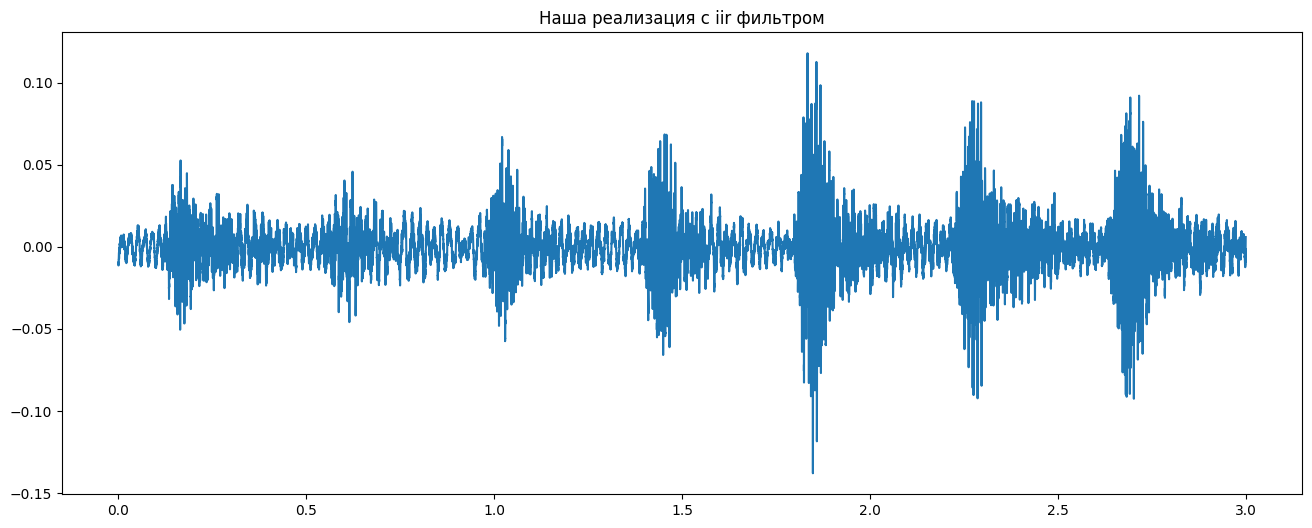

In [ ]:
path = os.getcwd() + '\\Jupyter\\10_Winter_Allegro.wav'
original_record, N1 = librosa.load(path, duration=3, sr=44100)

display(Audio(original_record, rate=N1))

Time = np.linspace(0, len(original_record) / N1, num=len(original_record))

plt.figure(figsize=(16, 6))
plt.title("Наша реализация c iir фильтром")
plt.plot(Time, original_record)
plt.show()

## Перевод из 44100 в 14700

In [ ]:
N2 = 14700

# Наша реализация c iir фильтром
our_imple_iir = freq_conv(original_record, N1, N2, 'iir')

# Наша реализация c fir фильтром
our_imple_fir = freq_conv(original_record, N1, N2, 'fir')

# Реализация librosa
librosa_imple = librosa.resample(original_record, orig_sr=N1, target_sr=N2)

print('Наша реализация c iir фильтром')
display(Audio(our_imple_iir, rate=N2))

print('Наша реализация c fir фильтром')
display(Audio(our_imple_fir, rate=N2))

print('Реализация librosa')
display(Audio(librosa_imple, rate=N2))


Наша реализация c iir фильтром


Наша реализация c fir фильтром


Реализация librosa


## Визуальное представление методов

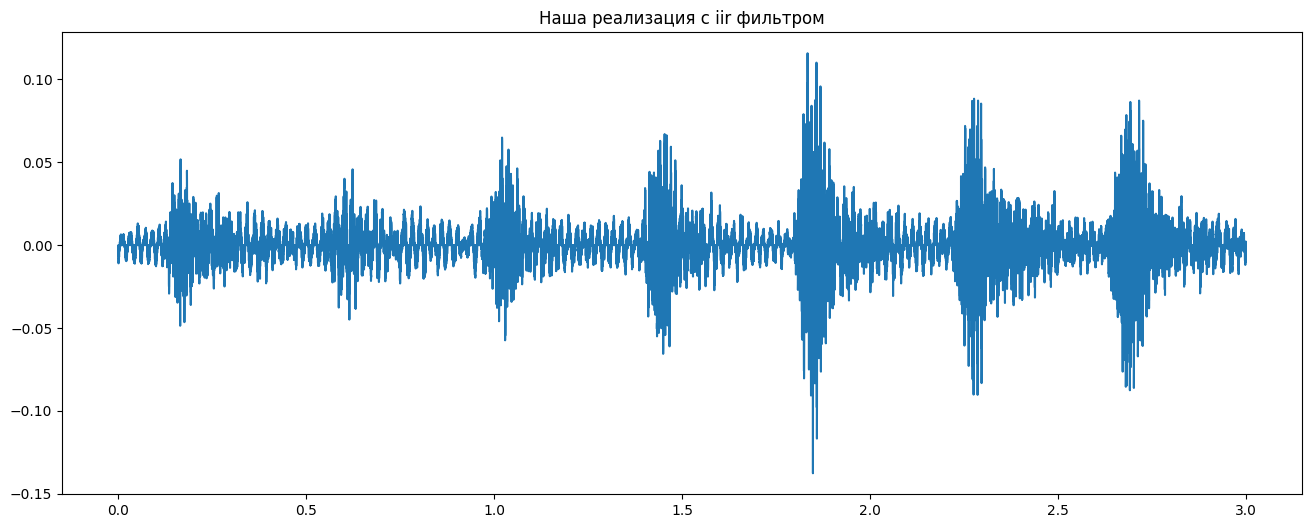

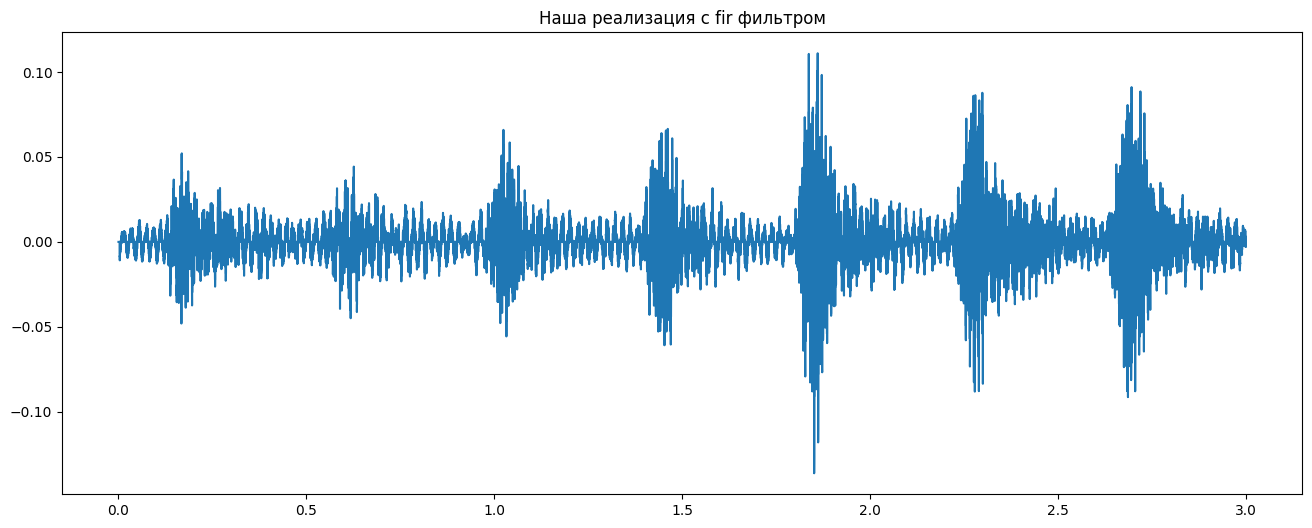

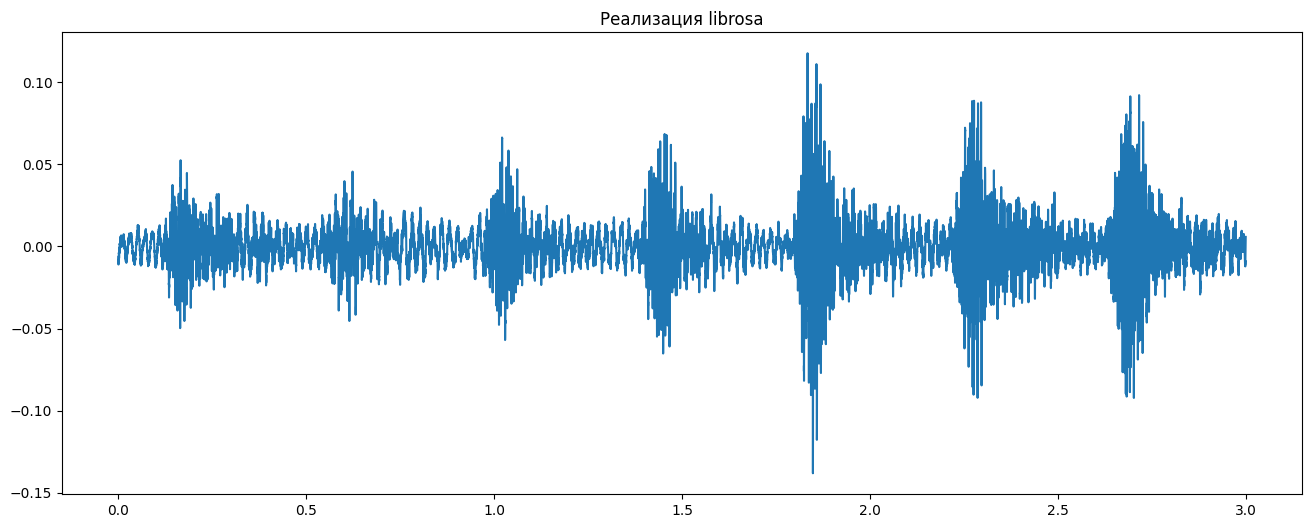

In [ ]:
Time = np.linspace(0, len(our_imple_iir) / N2, num=len(our_imple_iir))

plt.figure(figsize=(16, 6))
plt.title("Наша реализация c iir фильтром")
plt.plot(Time, our_imple_iir)
plt.show()

plt.figure(figsize=(16, 6))
plt.title("Наша реализация c fir фильтром")
plt.plot(Time, our_imple_fir)
plt.show()

plt.figure(figsize=(16, 6))
plt.title("Реализация librosa")
plt.plot(Time, librosa_imple)
plt.show()

## Численное сравнение методов

In [ ]:
print('Наша реализация c iir фильтром в среднем отличается от librosa на:')
print(f'{np.mean(np.abs(our_imple_iir - librosa_imple)):.4f}')

print('Наша реализация c fir фильтром в среднем отличается от librosa на:')
print(f'{np.mean(np.abs(our_imple_fir - librosa_imple)):.4f}')

print('Среднее значение в реализации librosa:')
print(f'{np.mean(np.abs(librosa_imple)):.4f}')

Наша реализация c iir фильтром в среднем отличается от librosa на:
0.0074
Наша реализация c fir фильтром в среднем отличается от librosa на:
0.0119
Среднее значение в реализации librosa:
0.0103


# Случай с N1 < N2

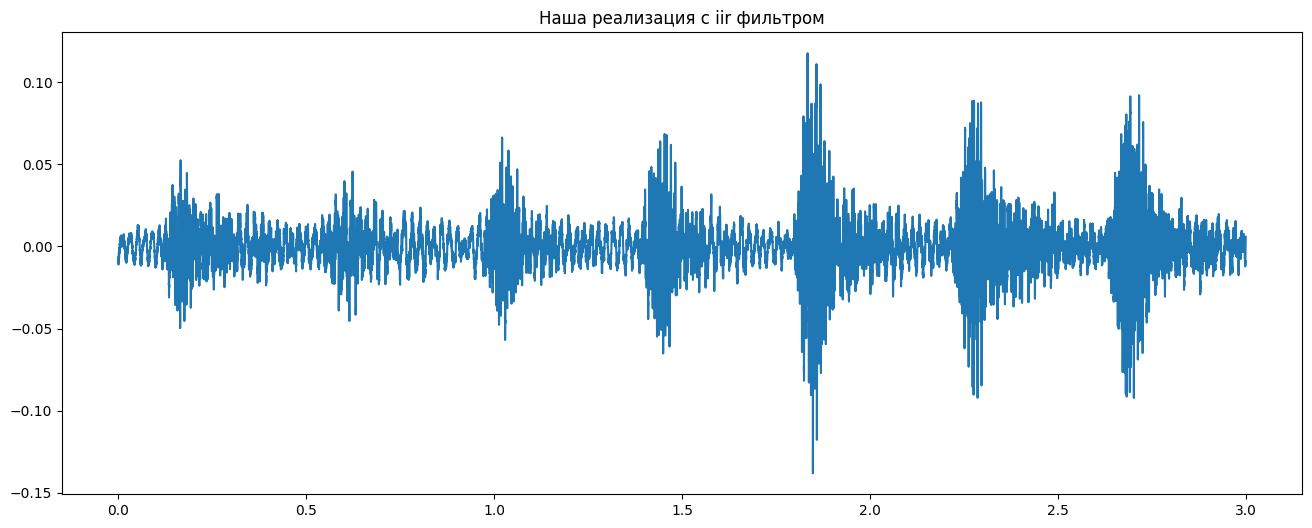

In [ ]:
path = os.getcwd() + '\\Jupyter\\10_Winter_Allegro.wav'
original_record, N1 = librosa.load(path, duration=3, sr=14700)

display(Audio(original_record, rate=N1))

Time = np.linspace(0, len(original_record) / N1, num=len(original_record))

plt.figure(figsize=(16, 6))
plt.title("Наша реализация c iir фильтром")
plt.plot(Time, original_record)
plt.show()

## Перевод из 14700 в 44100

In [ ]:
N2 = 44100

# Наша реализация c iir фильтром
our_imple_iir = freq_conv(original_record, N1, N2, 'iir')

# Наша реализация c fir фильтром
our_imple_fir = freq_conv(original_record, N1, N2, 'fir')

# Реализация librosa
librosa_imple = librosa.resample(original_record, orig_sr=N1, target_sr=N2)

print('Наша реализация c iir фильтром')
display(Audio(our_imple_iir, rate=N2))

print('Наша реализация c fir фильтром')
display(Audio(our_imple_fir, rate=N2))

print('Реализация librosa')
display(Audio(librosa_imple, rate=N2))

print()

Наша реализация c iir фильтром


Наша реализация c fir фильтром


Реализация librosa


## Визуальное представление методов

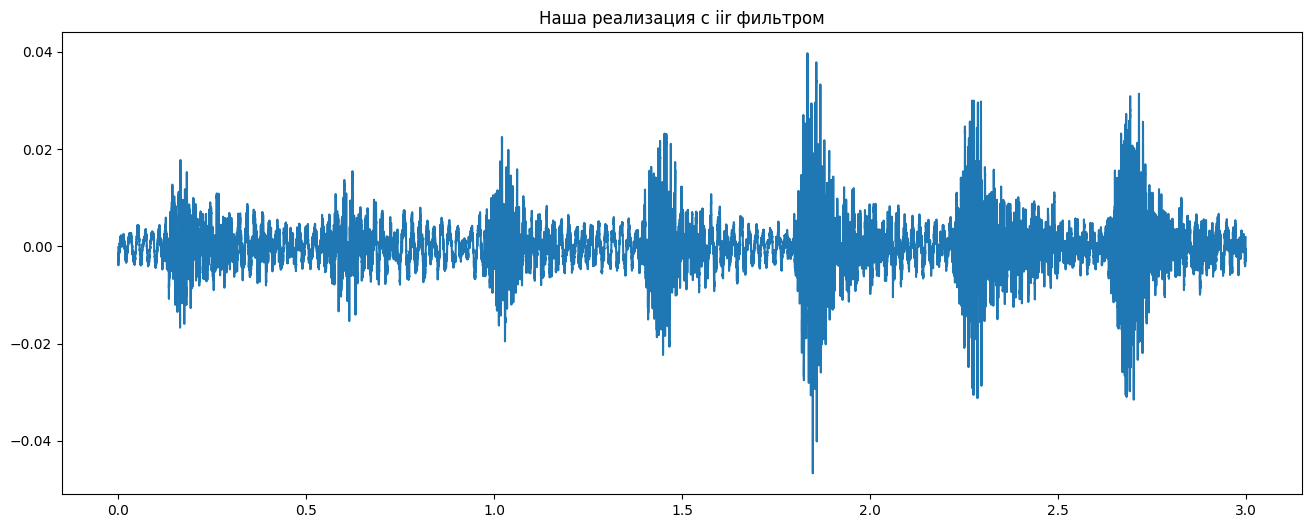

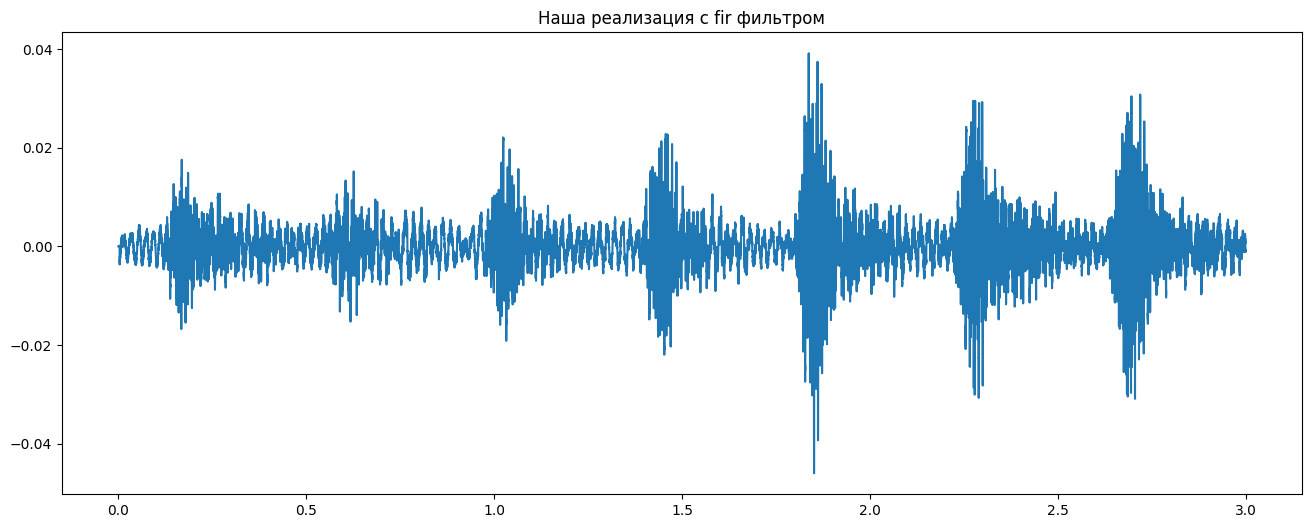

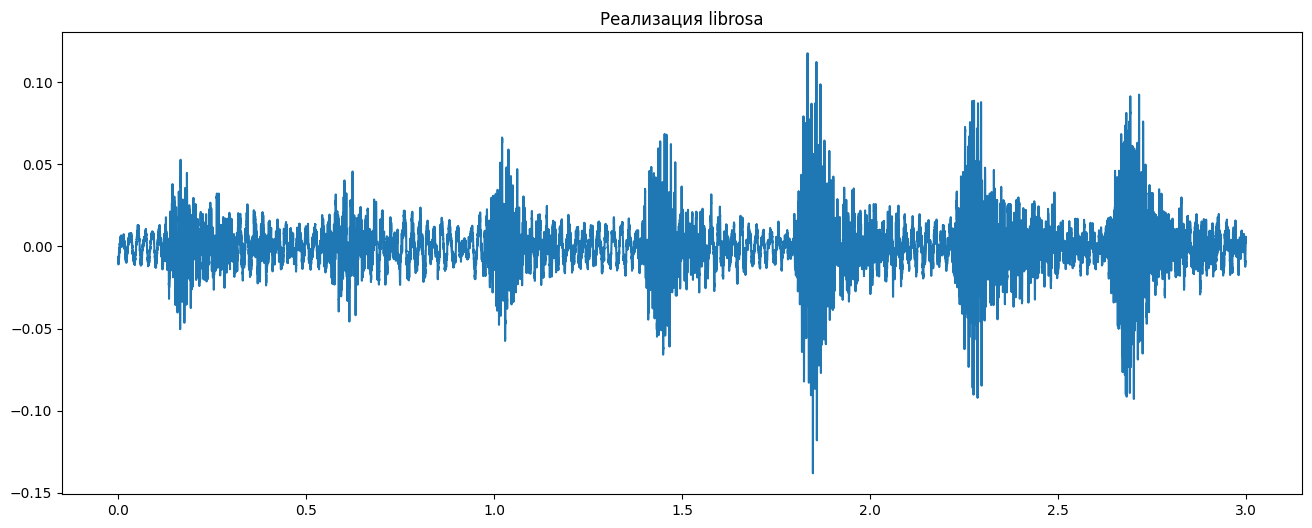

In [ ]:
Time = np.linspace(0, len(our_imple_iir) / N2, num=len(our_imple_iir))

plt.figure(figsize=(16, 6))
plt.title("Наша реализация c iir фильтром")
plt.plot(Time, our_imple_iir)
plt.show()

plt.figure(figsize=(16, 6))
plt.title("Наша реализация c fir фильтром")
plt.plot(Time, our_imple_fir)
plt.show()

plt.figure(figsize=(16, 6))
plt.title("Реализация librosa")
plt.plot(Time, librosa_imple)
plt.show()

## Численное сравнение методов

In [ ]:
print('Наша реализация c iir фильтром в среднем отличается от librosa на:')
print(f'{np.mean(np.abs(our_imple_iir - librosa_imple)):.4f}')

print('Наша реализация c fir фильтром в среднем отличается от librosa на:')
print(f'{np.mean(np.abs(our_imple_fir - librosa_imple)):.4f}')

print('Среднее значение в реализации librosa:')
print(f'{np.mean(np.abs(librosa_imple)):.4f}')

Наша реализация c iir фильтром в среднем отличается от librosa на:
0.0069
Наша реализация c fir фильтром в среднем отличается от librosa на:
0.0112
Среднее значение в реализации librosa:
0.0103


# Вывод

Если сравнивать методы на слух, то реализованный частотный конвертер хорошо справляется с переводом, когда начальная частота N1 меньше итоговой частоты N2, но при переводе, когда начальная частота N1 больше итоговой частоты N2, качество звука сильно страдает. При этом, если сравнивать работу методов численно, то можно заметить, что оба случая допускают примерно одинаковую ошибку и реализация с IIR фильтром справляется в среднем лучше, чем с FIR фильтром, но при этом даёт всё ещё достаточно большое отклонение. При визуальном сравнении трудно заметить какие-то различия у реализованного частотного конвертора и конвертера из библиотеки librosa.